<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/gd-test/SCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run this command if you want to remove your current folder

In [66]:
!rm -rf /content/lwhsi_dataset/
%mkdir -p /content/lwhsi_dataset
%cd /content/lwhsi_dataset

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/lwhsi_dataset


Loading some data from the 202104 collection of the Darpa Invisible Headlights dataset

In [67]:
!pip install spectral
!pip install awscli -q
!pip install laspy

In [68]:
!aws s3 sync \
  s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/ \
  /content/lwhsi_dataset/ \
  --no-sign-request \
  --exclude "*" \
  --include "*LWHSI*.hdr" \
  --include "*LWHSI*.bsq" \
  --include "*.las"

download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.hdr
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.hdr
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect2_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect2_DistStA.hdr
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.bsq to ./IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.bsq
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect3_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect3_DistStA.hdr
download: s3://

Plotting the images

/tmp/ipykernel_10056/808231010.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


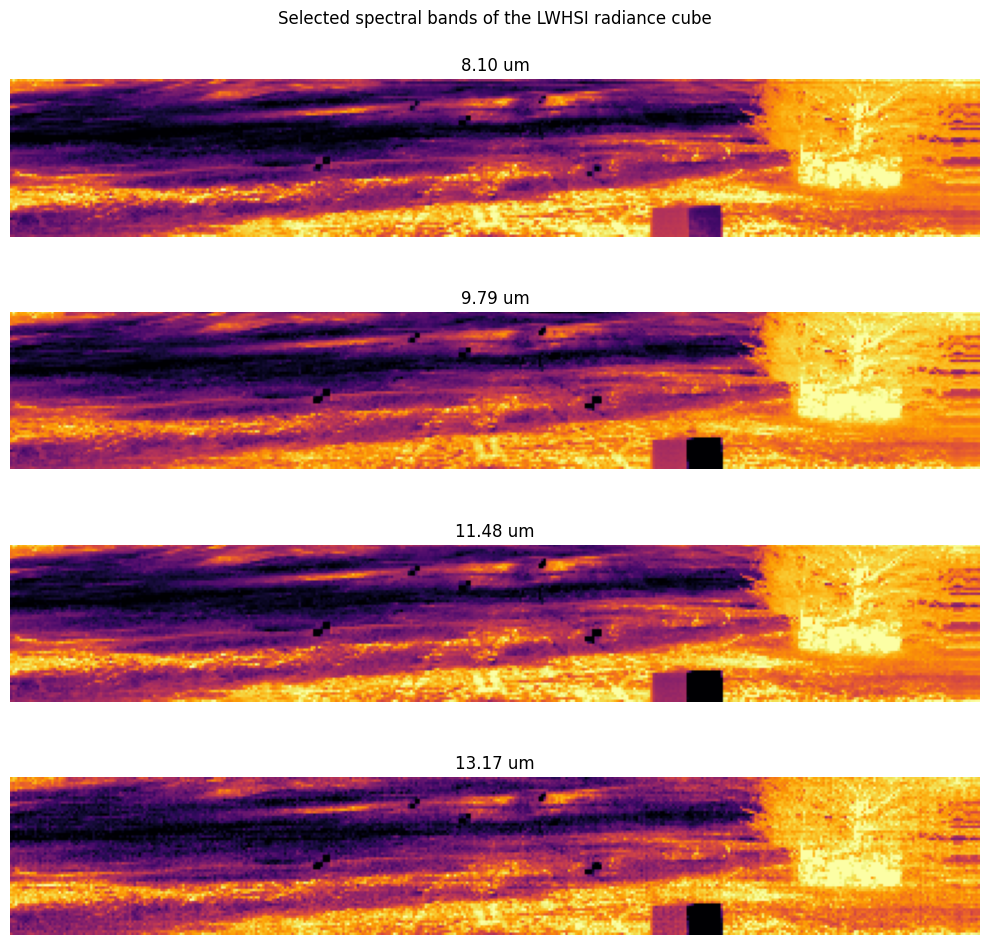

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

hdr_files = sorted(glob.glob('/content/lwhsi_dataset/*.hdr', recursive=True))
lidar_files = sorted(glob.glob('/content/lwhsi_dataset/*.las', recursive=True))

if not (hdr_files and lidar_files):
    raise FileNotFoundError(".hdr or .las files missing")

# There's different images that you can check them by replacing the idx value
idx = 1

try:

  img = envi.open(hdr_files[idx])
  radiance_hsi = img.load()

  if hasattr(img, 'bands') and 'wavelength' in img.metadata:
      wavelengths_um = [float(w) for w in img.metadata['wavelength']]
  else:
      num_bandas = radiance_hsi.shape[2]
      wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

  band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
  plot_stride = 4

  fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
  axes = axes.ravel()

  for ax, band_index in zip(axes, band_indices):
      band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
      im = ax.imshow(robust_image(band_image), cmap='inferno')
      ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
      ax.axis('off')

  fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
  plt.tight_layout()
  plt.show()

except Exception as e:
  print(e)


Now you can select whatever band you want (the images have a total of 256 bands)

/tmp/ipykernel_10056/808231010.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


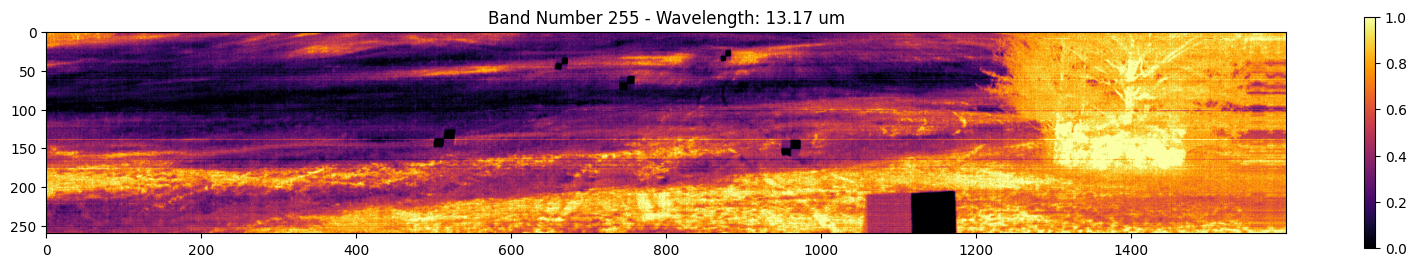

In [70]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

# Change the current band with this variable
selected_band = 255

try:

  im = axes.imshow(robust_image(radiance_hsi[:, :, selected_band]), cmap='inferno')
  axes.set_title(f'Band Number {selected_band} - Wavelength: {wavelengths_um[selected_band]:.2f} um')

  axes.label_outer()
  plt.colorbar(im, ax=axes)
  plt.show()

except Exception as e:
  print(e)


Now select the pixels you want to plot (image shape is (260,1600,256)) on the image

In [71]:
# Format is (x,y, # pixel, "Pixel #")

selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

We now define the blackbody function

In [72]:
'''
MICROFLICK_PER_W_M2 = 100.0

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)
  '''

'\nMICROFLICK_PER_W_M2 = 100.0\n\ndef blackbody_radiance(wavelenghts_um, temperature_k):\n    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""\n    h = 6.62607015e-34\n    c = 299792458.0\n    k = 1.380649e-23\n\n    wavelength_m = wavelengths_um * 1e-6\n\n    x = (h * c) / (wavelength_m * k * temperature_k)\n\n    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6\n    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2\n\n    return radiance_microflicks.astype(np.float32)\n  '

In [73]:
MICROFLICK_PER_W_M2 = 100.0
def blackbody_radiance(wavelengths_um, temperature_k):
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelengths_um = np.asarray(wavelengths_um, dtype=np.float32)
    temperature_k = np.asarray(temperature_k, dtype=np.float32)

    # coloca wavelength en el último eje, temperature en los ejes espaciales
    wavelength_m = wavelengths_um.reshape((1,) * temperature_k.ndim + wavelengths_um.shape) * 1e-6
    temperature_k_b = temperature_k[..., None]

    x = (h * c) / (wavelength_m * k * temperature_k_b)
    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    return (radiance_w_m2_sr_um * MICROFLICK_PER_W_M2).astype(np.float32)

Now select the temperature in Kelvin

In [74]:
# Modify the temperature value with this variable
temperature_k = 300

/tmp/ipykernel_10056/808231010.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


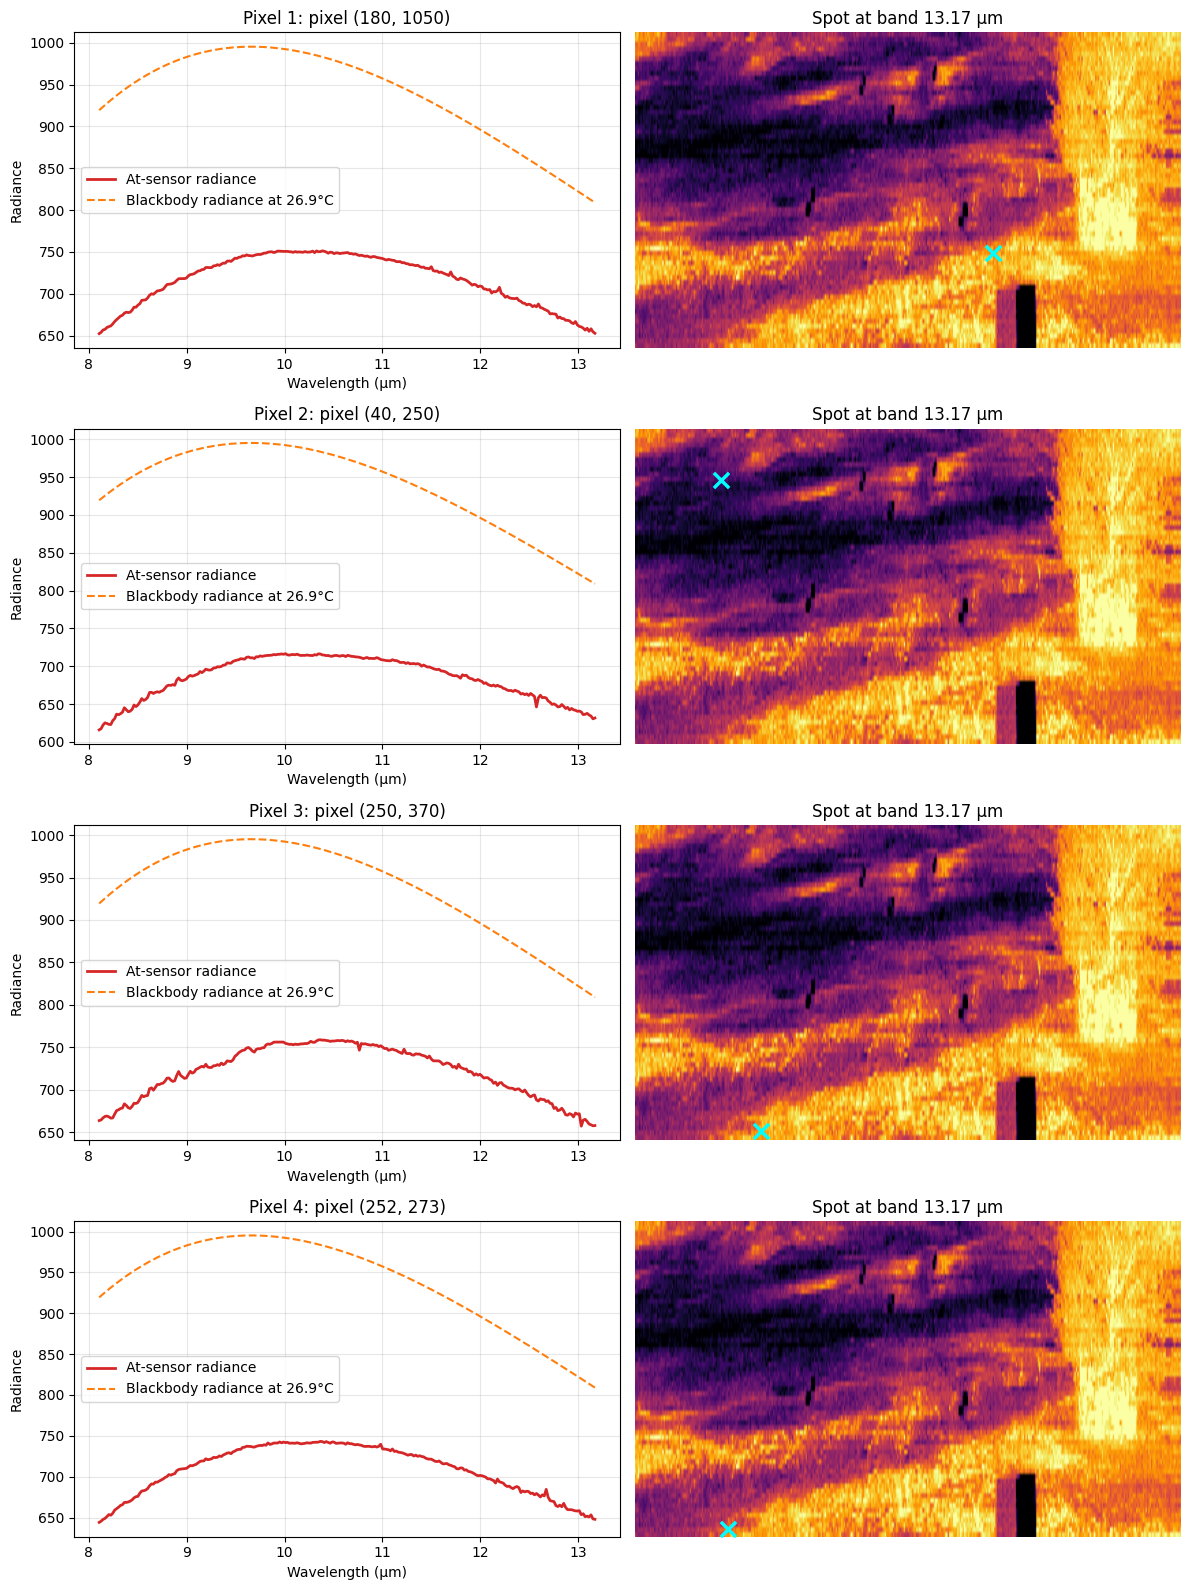

In [75]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_band = int(np.argmin(np.abs(wavelengths_um - 10.0)))
context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='auto')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

------

In [76]:
def transmittance(depth_map):
    """Atmospheric transmittance for every wavelength using attenuation in dB/m."""
    optical_loss_db = attenuation_db_per_m[None, None, :] * depth_map[:, :, None]
    return (10 ** (-optical_loss_db / 10.0)).astype(np.float32)

In [77]:
def d_blackbody_radiance_d_temperature(wavelengths_um,temperature_k_map):
    """Derivative of blackbody radiance with respect to temperature in Kelvin."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um[None, None, :] * 1e-6
    temperature_k_map = temperature_k_map[:, :, None]

    x = (h * c) / (wavelength_m * k * temperature_k_map)
    exp_x = np.exp(x)
    scale = (2.0 * h * c**2) / wavelength_m**5 * 1e-6 * MICROFLICK_PER_W_M2
    derivative = scale * exp_x * x / (temperature_k_map * (exp_x - 1.0) ** 2)
    return derivative.astype(np.float32)


In [78]:
def manual_gradient_descent(
    observed_radiance,
    air_temperature_c,
    downwelling_radiance,
    iterations=800,
    record_every=50,
    initial_emissivity=0.9,
    initial_depth=20.0,
    initial_temperature_c=20.0,
    learning_rate_emissivity=1e-2,
    learning_rate_depth=1e2,
    learning_rate_temperature=20.0,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    """Estimate emissivity, depth, and object temperature.

    T_air and the incident downwelling radiance are fixed inputs.
    They are used by the RTE but are not estimated here.
    """
    observed_radiance = np.asarray(
        observed_radiance,
        dtype=np.float32,
    )
    n_bands = observed_radiance.shape[2]
    radiance_scale = np.maximum(
        np.mean(
            observed_radiance,
            axis=2,
            keepdims=True,
        ),
        1.0,
    )

    predicted_emissivity = np.full_like(
        observed_radiance,
        initial_emissivity,
        dtype=np.float32,
    )
    predicted_depth = np.full(
        observed_radiance.shape[:2],
        initial_depth,
        dtype=np.float32,
    )
    predicted_temperature_k = np.full(
        observed_radiance.shape[:2],
        initial_temperature_c + 273.15,
        dtype=np.float32,
    )

    # ============ STUDENT CODE BLOCK: FIXED TERMS ============
    air_temperature_k = np.array(
        [[air_temperature_c + 273.15]],
        dtype=np.float32,
    )
    air_blackbody = blackbody_radiance(
        wavelengths_um, air_temperature_k
    )

    fixed_downwelling = np.asarray(
        downwelling_radiance,
        dtype=np.float32,
    )
    if fixed_downwelling.ndim == 1:
        fixed_downwelling = (
            fixed_downwelling[None, None, :]
        )
    if fixed_downwelling.shape[-1] != n_bands:
        raise ValueError(
            'downwelling_radiance must have one value per band.'
        )
    try:
        fixed_downwelling = np.broadcast_to(
            fixed_downwelling,
            observed_radiance.shape,
        )
    except ValueError as exc:
        raise ValueError(
            'downwelling_radiance must broadcast to '
            'observed_radiance.'
        ) from exc
    # ==========================================================

    attenuation_factor = (
        -(np.log(10.0) / 10.0)
        * attenuation_db_per_m[None, None, :]
    )
    history = []

    for iteration in range(iterations + 1):
        blackbody = blackbody_radiance(
            wavelengths_um, predicted_temperature_k
        )
        transmittance_term = transmittance(
            predicted_depth
        )

        # ============ STUDENT CODE BLOCK: FORWARD MODEL ============
        surface_leaving = (
            predicted_emissivity * blackbody
            + (1.0 - predicted_emissivity)
            * fixed_downwelling
        )
        prediction = (
            transmittance_term * surface_leaving
            + (1.0 - transmittance_term)
            * air_blackbody
        )
        # ===========================================================

        normalized_error = (
            prediction - observed_radiance
        ) / radiance_scale
        loss = np.mean(normalized_error**2)

        if (
            iteration % record_every == 0
            or iteration == iterations
        ):
            row = {
                'iteration': iteration,
                'normalized_radiance_rmse': float(
                    np.sqrt(loss)
                ),
            }
            if depth_truth is not None:
                row['depth_rmse'] = float(
                    np.sqrt(
                        np.mean(
                            (
                                predicted_depth
                                - depth_truth
                            ) ** 2
                        )
                    )
                )
            if temperature_truth_c is not None:
                predicted_temperature_c = (
                    predicted_temperature_k - 273.15
                )
                row['temperature_rmse'] = float(
                    np.sqrt(
                        np.mean(
                            (
                                predicted_temperature_c
                                - temperature_truth_c
                            ) ** 2
                        )
                    )
                )
            if emissivity_truth is not None:
                row['emissivity_rmse'] = float(
                    np.sqrt(
                        np.mean(
                            (
                                predicted_emissivity
                                - emissivity_truth
                            ) ** 2
                        )
                    )
                )
            history.append(row)

        if iteration == iterations:
            break

        residual_factor = (
            (2.0 / n_bands)
            * (prediction - observed_radiance)
            / (radiance_scale**2)
        )

        # ============ STUDENT CODE BLOCK: GRADIENTS ============
        grad_emissivity = (
            residual_factor
            * transmittance_term
            * (blackbody - fixed_downwelling)
        )

        grad_depth = np.sum(
            residual_factor
            * (surface_leaving - air_blackbody)
            * attenuation_factor
            * transmittance_term,
            axis=2,
        )
        # =======================================================

        grad_temperature = np.sum(
            residual_factor
            * predicted_emissivity
            * transmittance_term
            * d_blackbody_radiance_d_temperature(
                wavelengths_um, predicted_temperature_k
            ),
            axis=2,
        )

        predicted_emissivity = np.clip(
            predicted_emissivity
            - learning_rate_emissivity
            * grad_emissivity,
            0.6,
            1.0,
        )
        predicted_depth = np.clip(
            predicted_depth
            - learning_rate_depth * grad_depth,
            0.0,
            120.0,
        )
        predicted_temperature_k = np.clip(
            predicted_temperature_k
            - learning_rate_temperature
            * grad_temperature,
            273.15,
            313.15,
        )

    return {
        'emissivity': predicted_emissivity,
        'depth': predicted_depth,
        'temperature_c': (
            predicted_temperature_k - 273.15
        ),
        'history': history,
    }


In [79]:
import numpy as np

# Assuming dimensions based on radiance_hsi.shape (260, 1600, 256)
h, w, bands = radiance_hsi.shape

# Placeholder for depth (2D array). Replace with actual data if available.
depth = np.full((h, w), 20.0, dtype=np.float32) # Example: initial depth of 20m

# Placeholder for temperature_c (2D array). Replace with actual data if available.
temperature_c = np.full((h, w), 20.0, dtype=np.float32) # Example: initial temp of 20 C

# Placeholder for emissivity (3D array). Replace with actual data if available.
emissivity = np.full((h, w, bands), 0.9, dtype=np.float32) # Example: initial emissivity of 0.9

# Placeholder for air_temperature_c (scalar). Replace with actual data if available.
air_temperature_c = 25.0 # Example: air temperature of 25 C

# Placeholder for downwelling_radiance (1D array for all bands). Replace with actual data if available.
downwelling_radiance = np.full(bands, 100.0, dtype=np.float32) # Example: constant downwelling radiance for all bands

# Placeholder for attenuation_db_per_m (1D array for all bands). Replace with actual data if available.
attenuation_db_per_m = np.full(bands, 0.1, dtype=np.float32) # Example: 0.1 dB/m attenuation for all bands

In [80]:
backward_stride = 16

observed_small = radiance_hsi[::backward_stride, ::backward_stride, :]
depth_truth_small = depth[::backward_stride, ::backward_stride]
temperature_truth_small = temperature_c[::backward_stride, ::backward_stride]
emissivity_truth_small = emissivity[::backward_stride, ::backward_stride, :]

inverse_result = manual_gradient_descent(
    observed_small,
    air_temperature_c=air_temperature_c,
    downwelling_radiance=downwelling_radiance,
    iterations=3000,
    record_every=50,
    depth_truth=depth_truth_small,
    temperature_truth_c=temperature_truth_small,
    emissivity_truth=emissivity_truth_small,
)

print('Estimated emissivity:', inverse_result['emissivity'].shape)
print('Estimated depth:', inverse_result['depth'].shape)
print('Estimated temperature:', inverse_result['temperature_c'].shape)
print('Final metrics:', inverse_result['history'][-1])


Estimated emissivity: (17, 100, 256)
Estimated depth: (17, 100)
Estimated temperature: (17, 100)
Final metrics: {'iteration': 3000, 'normalized_radiance_rmse': 0.011518306098878384, 'depth_rmse': 14.110839063527614, 'temperature_rmse': 8.031123161315918, 'emissivity_rmse': 0.002442495431751013}


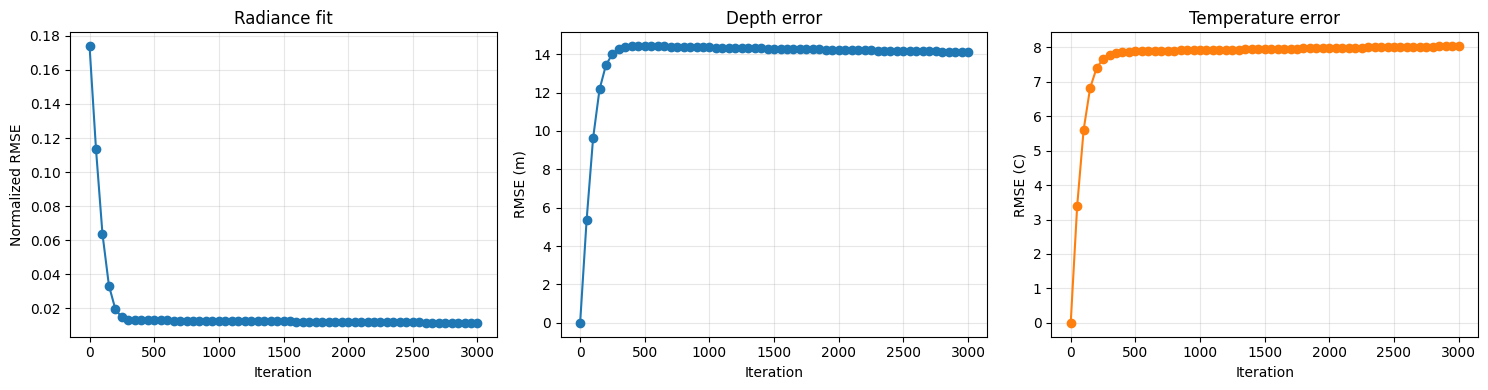

In [81]:
history = inverse_result['history']
iterations = [row['iteration'] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(iterations, [row['normalized_radiance_rmse'] for row in history], marker='o')
axes[0].set_title('Radiance fit')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalized RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [row['depth_rmse'] for row in history], marker='o', color='tab:blue')
axes[1].set_title('Depth error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (m)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, [row['temperature_rmse'] for row in history], marker='o', color='tab:orange')
axes[2].set_title('Temperature error')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE (C)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


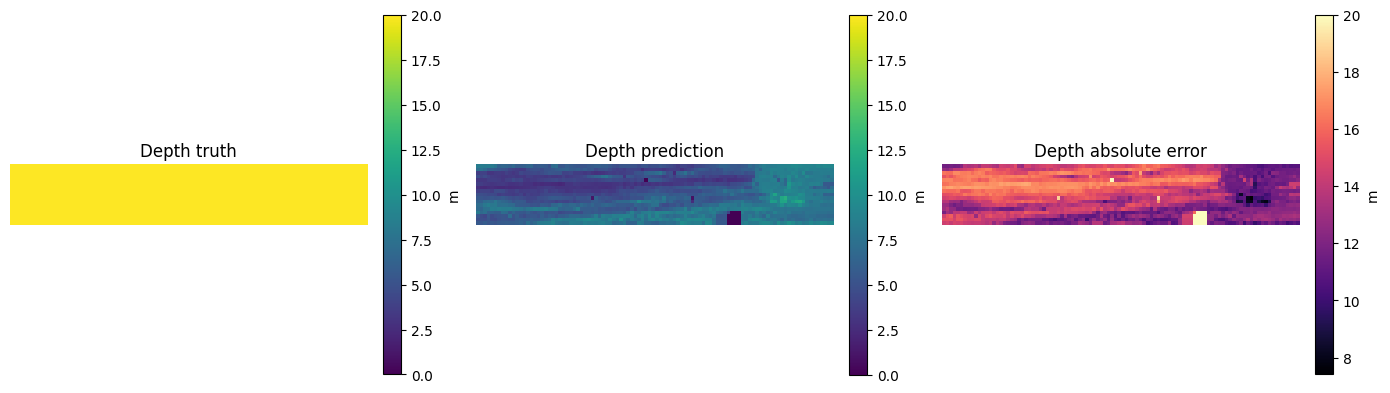

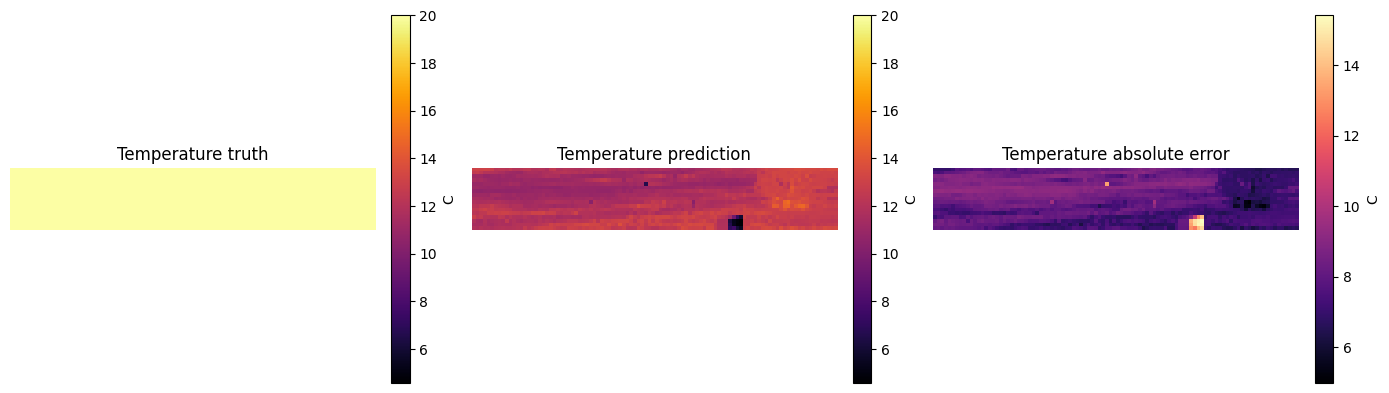

In [82]:
def plot_truth_prediction_error(truth, prediction, title, unit, cmap='viridis'):
    error = np.abs(prediction - truth)
    vmin = min(float(np.min(truth)), float(np.min(prediction)))
    vmax = max(float(np.max(truth)), float(np.max(prediction)))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    im0 = axes[0].imshow(truth, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'{title} truth')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=unit)

    im1 = axes[1].imshow(prediction, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'{title} prediction')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label=unit)

    im2 = axes[2].imshow(error, cmap='magma')
    axes[2].set_title(f'{title} absolute error')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label=unit)

    plt.tight_layout()
    plt.show()

plot_truth_prediction_error(depth_truth_small, inverse_result['depth'], 'Depth', 'm')
plot_truth_prediction_error(
    temperature_truth_small, inverse_result['temperature_c'], 'Temperature', 'C', cmap='inferno'
)


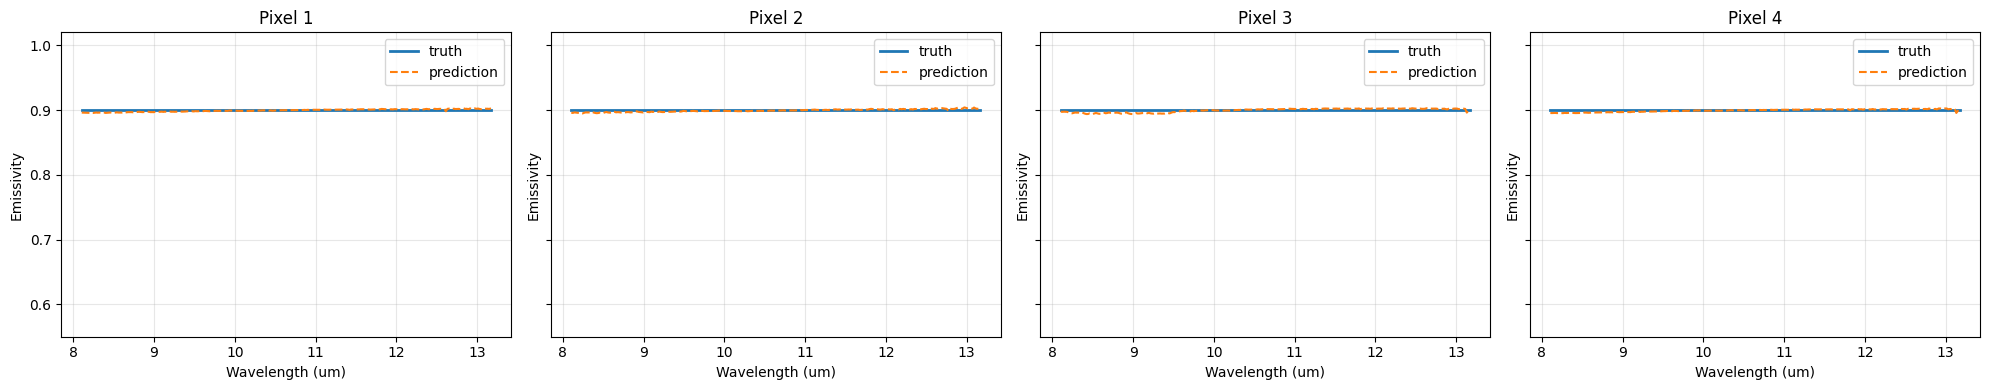

Selected-pixel emissivity RMSE: 0.0023674408439546824


In [83]:
selected_rows = np.array([pixel[0] for pixel in selected_pixels])
selected_cols = np.array([pixel[1] for pixel in selected_pixels])
selected_names = [pixel[3] for pixel in selected_pixels]

selected_small_rows = selected_rows // backward_stride
selected_small_cols = selected_cols // backward_stride
emissivity_truth_pixels = emissivity[selected_rows, selected_cols, :]
emissivity_prediction_pixels = inverse_result['emissivity'][selected_small_rows, selected_small_cols, :]

fig, axes = plt.subplots(1, len(selected_names), figsize=(5 * len(selected_names), 4), sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for i, (ax, material_name) in enumerate(zip(axes, selected_names)):
    ax.plot(wavelengths_um, emissivity_truth_pixels[i, :], label='truth', linewidth=2)
    ax.plot(wavelengths_um, emissivity_prediction_pixels[i, :], label='prediction', linestyle='--')
    ax.set_title(material_name)
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Emissivity')
    ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Selected-pixel emissivity RMSE:', float(np.sqrt(np.mean((emissivity_prediction_pixels - emissivity_truth_pixels) ** 2))))


In [84]:
def invert_blackbody_temperature(wavelength_um, radiance_microflicks, emissivity=1.0):
    """Invierte la ley de Planck: dada una radiancia observada a una longitud
    de onda, resuelve la temperatura de cuerpo negro que la produciría."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelength_um * 1e-6
    L_w_m2_sr_um = np.asarray(radiance_microflicks, dtype=np.float64) / (MICROFLICK_PER_W_M2 * emissivity)
    L_w_m2_sr_m = np.maximum(L_w_m2_sr_um, 1e-12) * 1e6

    ratio = (2.0 * h * c**2) / (wavelength_m**5 * L_w_m2_sr_m)
    temperature_k = (h * c) / (wavelength_m * k * np.log1p(ratio))
    return temperature_k.astype(np.float32)

Usando banda a 10.01 um


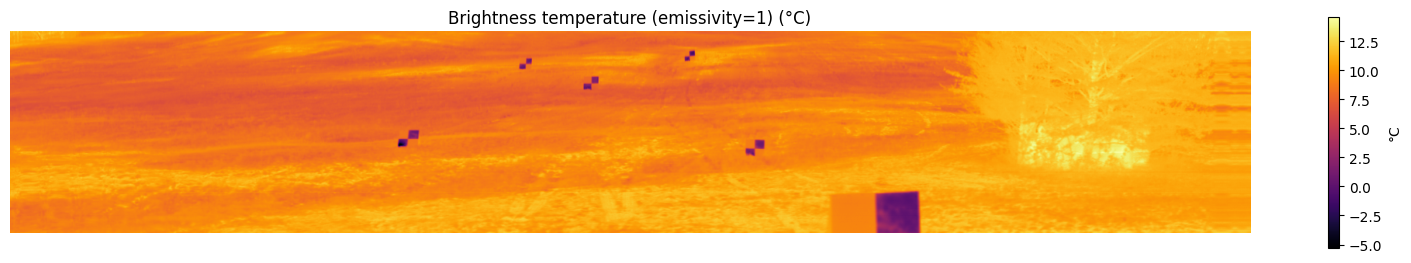

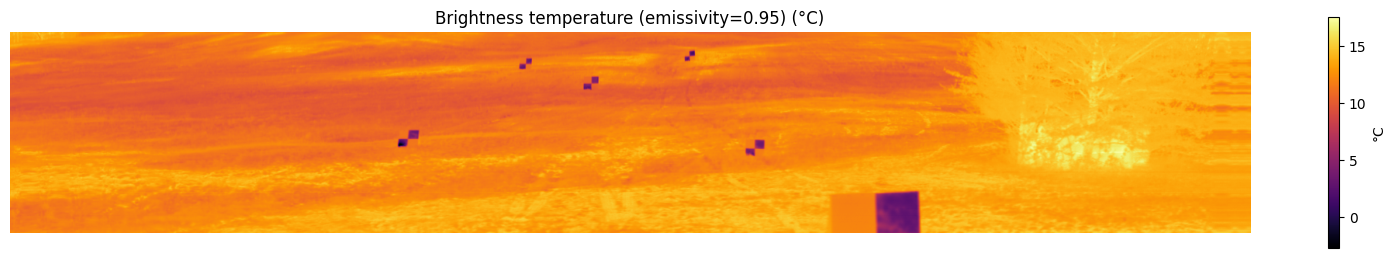

In [85]:
def compute_temperature_image(radiance_hsi, wavelengths_um, band_wavelength=10.0, emissivity=1.0):
    """Equivalente al range_img del LiDAR, pero para temperatura.
    Elige UNA banda dentro de una ventana atmosférica limpia (~10-11 um es buena
    para LWIR, evita bandas con fuerte absorción de ozono/vapor de agua ~9.6 y ~6-7 um).
    """
    band_idx = int(np.argmin(np.abs(np.asarray(wavelengths_um) - band_wavelength)))
    wl = wavelengths_um[band_idx]
    radiance_band = radiance_hsi[:, :, band_idx]

    temperature_img = invert_blackbody_temperature(wl, radiance_band, emissivity=emissivity)
    return temperature_img, wl

def plot_temperature_image(temperature_img, title="Brightness temperature", in_celsius=True):
    img = temperature_img - 273.15 if in_celsius else temperature_img
    unit = "°C" if in_celsius else "K"

    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(img, cmap='inferno')
    ax.set_title(f"{title} ({unit})")
    ax.axis('off')
    plt.colorbar(im, ax=ax, label=unit)
    plt.show()

# Uso, calcado del patrón que usó tu compañero para LiDAR:
temperature_img, used_wavelength = compute_temperature_image(
    radiance_hsi, wavelengths_um, band_wavelength=10.0, emissivity=1.0
)
print(f"Usando banda a {used_wavelength:.2f} um")
plot_temperature_image(temperature_img, title="Brightness temperature (emissivity=1)")

# opcional: con una emisividad típica de terreno natural en vez de 1.0
temperature_img_e95, _ = compute_temperature_image(
    radiance_hsi, wavelengths_um, band_wavelength=10.0, emissivity=0.95
)
plot_temperature_image(temperature_img_e95, title="Brightness temperature (emissivity=0.95)")

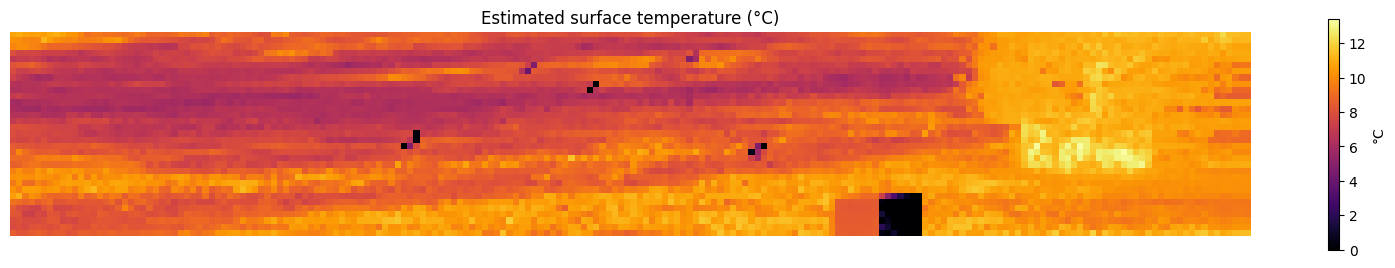

{'iteration': 0, 'normalized_radiance_rmse': 0.110711470246315, 'depth_rmse': 0.0, 'temperature_rmse': 7.887182712554932, 'emissivity_rmse': 0.0}
{'iteration': 100, 'normalized_radiance_rmse': 0.07395327836275101, 'depth_rmse': 9.445013291135696, 'temperature_rmse': 8.935867309570312, 'emissivity_rmse': 2.0362367649795488e-05}
{'iteration': 200, 'normalized_radiance_rmse': 0.042154110968112946, 'depth_rmse': 16.21661516535138, 'temperature_rmse': 9.67872142791748, 'emissivity_rmse': 3.677832864923403e-05}
{'iteration': 300, 'normalized_radiance_rmse': 0.02576916664838791, 'depth_rmse': 18.771082407474577, 'temperature_rmse': 10.134310722351074, 'emissivity_rmse': 4.86194621771574e-05}
{'iteration': 400, 'normalized_radiance_rmse': 0.017848949879407883, 'depth_rmse': 19.674121061925785, 'temperature_rmse': 10.440116882324219, 'emissivity_rmse': 5.8333640481578186e-05}
{'iteration': 500, 'normalized_radiance_rmse': 0.013879080303013325, 'depth_rmse': 19.93137350888322, 'temperature_rmse'

In [86]:
# ---- 1. wavelengths ya los tienes de la carga ENVI ----
wavelengths_um = np.array(wavelengths_um, dtype=np.float32)
n_bands = radiance_hsi.shape[2]

# ---- 2. parámetros físicos fijos (mientras no tengas calibración real) ----
attenuation_db_per_m = np.full(n_bands, 0.1, dtype=np.float32)   # TODO: reemplazar si encuentras cal real
air_temperature_c = 20.0                                         # TODO: reemplazar si hay log de temp. ambiente
downwelling_radiance = blackbody_radiance(
    wavelengths_um, np.float32(air_temperature_c + 273.15 - 5)   # aprox: cielo unos grados más frío que el aire
)

# ---- 3. downsample, igual que hizo tu compañero con max_points ----
stride = 8
observed_small = radiance_hsi[::stride, ::stride, :]

# Prepare truth values for the current stride
depth_truth_small = depth[::stride, ::stride]
temperature_truth_small = temperature_c[::stride, ::stride]
emissivity_truth_small = emissivity[::stride, ::stride, :]

# ---- 4. warm start: arranca la temperatura desde la brillo-temperatura,
#         en vez de un valor plano — converge más rápido y más estable ----
band_idx = int(np.argmin(np.abs(wavelengths_um - 10.0)))
warm_start_temp_c = np.squeeze(invert_blackbody_temperature(
    wavelengths_um[band_idx], observed_small[:, :, band_idx], emissivity=0.95
)) - 273.15

# ---- 5. correr la inversión (SIN los learning rates originales de 1e6!) ----
result = manual_gradient_descent(
    observed_small,
    air_temperature_c=air_temperature_c,
    downwelling_radiance=downwelling_radiance,
    iterations=1500,
    record_every=100,
    initial_temperature_c=warm_start_temp_c,   # mapa, no escalar
    initial_depth=20.0,
    initial_emissivity=0.9,
    learning_rate_emissivity=5e-3,
    learning_rate_depth=2e2,
    learning_rate_temperature=5.0,
    depth_truth=depth_truth_small, # Pass depth truth
    temperature_truth_c=temperature_truth_small, # Pass temperature truth
    emissivity_truth=emissivity_truth_small, # Pass emissivity truth
)

# ---- 6. graficar, igual que plot_range_image ----
def plot_temperature_image(temperature_c, title="Estimated surface temperature"):
    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(temperature_c, cmap='inferno')
    ax.set_title(f"{title} (°C)")
    ax.axis('off')
    plt.colorbar(im, ax=ax, label="°C")
    plt.show()

plot_temperature_image(result['temperature_c'])

for row in result['history']:
    print(row)

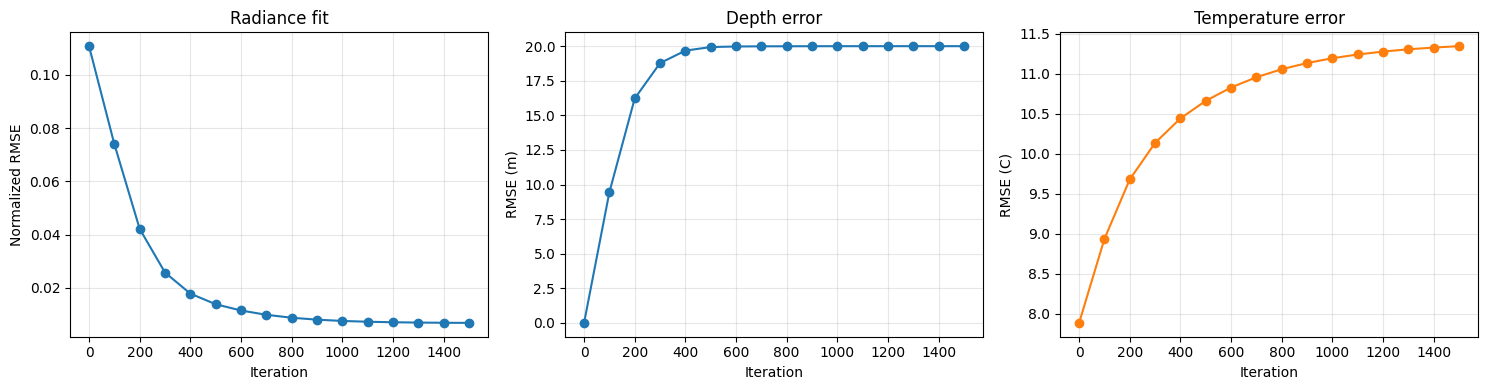

In [87]:
history = result['history']
iterations = [row['iteration'] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(iterations, [row['normalized_radiance_rmse'] for row in history], marker='o')
axes[0].set_title('Radiance fit')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalized RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [row['depth_rmse'] for row in history], marker='o', color='tab:blue')
axes[1].set_title('Depth error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (m)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, [row['temperature_rmse'] for row in history], marker='o', color='tab:orange')
axes[2].set_title('Temperature error')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE (C)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


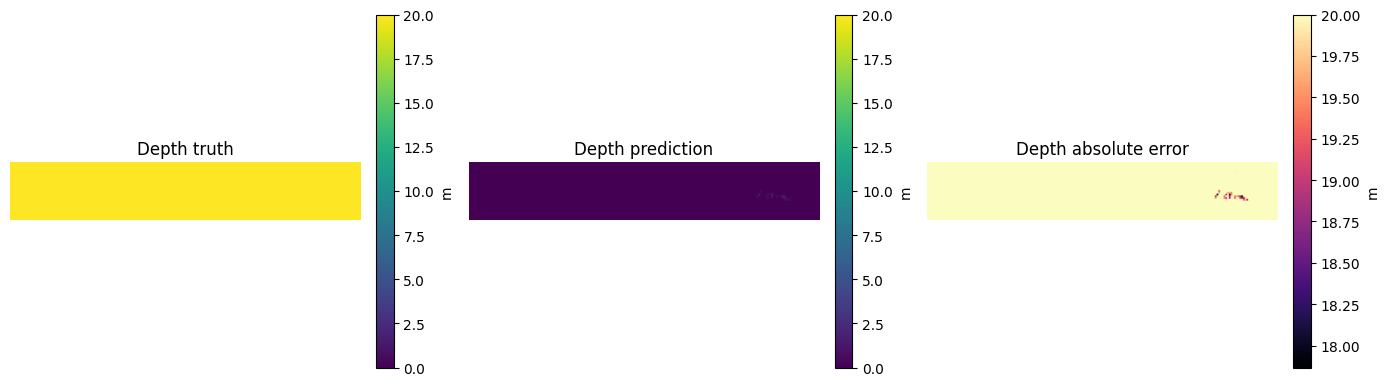

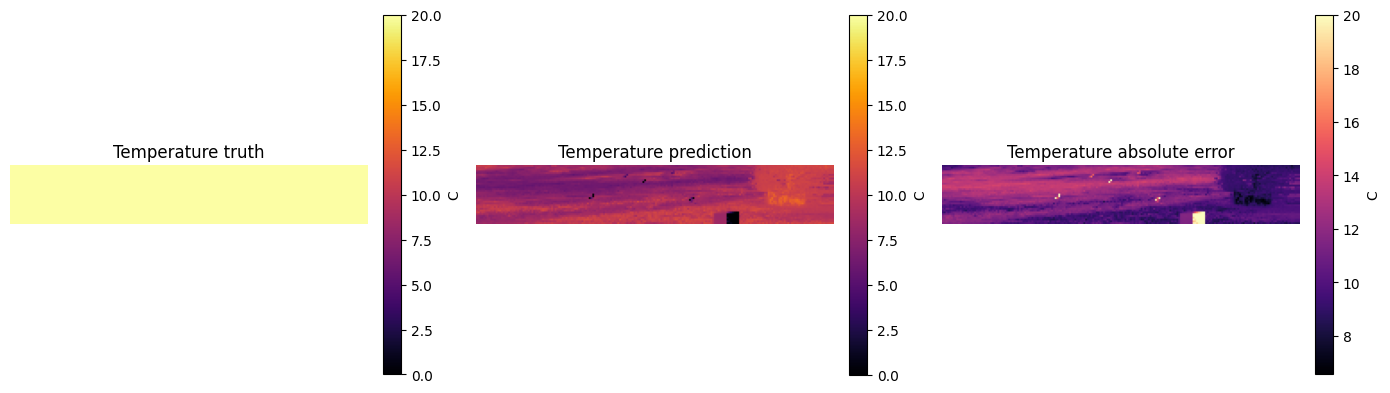

In [88]:
def plot_truth_prediction_error(truth, prediction, title, unit, cmap='viridis'):
    error = np.abs(prediction - truth)
    vmin = min(float(np.min(truth)), float(np.min(prediction)))
    vmax = max(float(np.max(truth)), float(np.max(prediction)))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    im0 = axes[0].imshow(truth, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'{title} truth')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=unit)

    im1 = axes[1].imshow(prediction, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'{title} prediction')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label=unit)

    im2 = axes[2].imshow(error, cmap='magma')
    axes[2].set_title(f'{title} absolute error')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label=unit)

    plt.tight_layout()
    plt.show()

plot_truth_prediction_error(depth_truth_small, result['depth'], 'Depth', 'm')
plot_truth_prediction_error(
    temperature_truth_small, result['temperature_c'], 'Temperature', 'C', cmap='inferno'
)


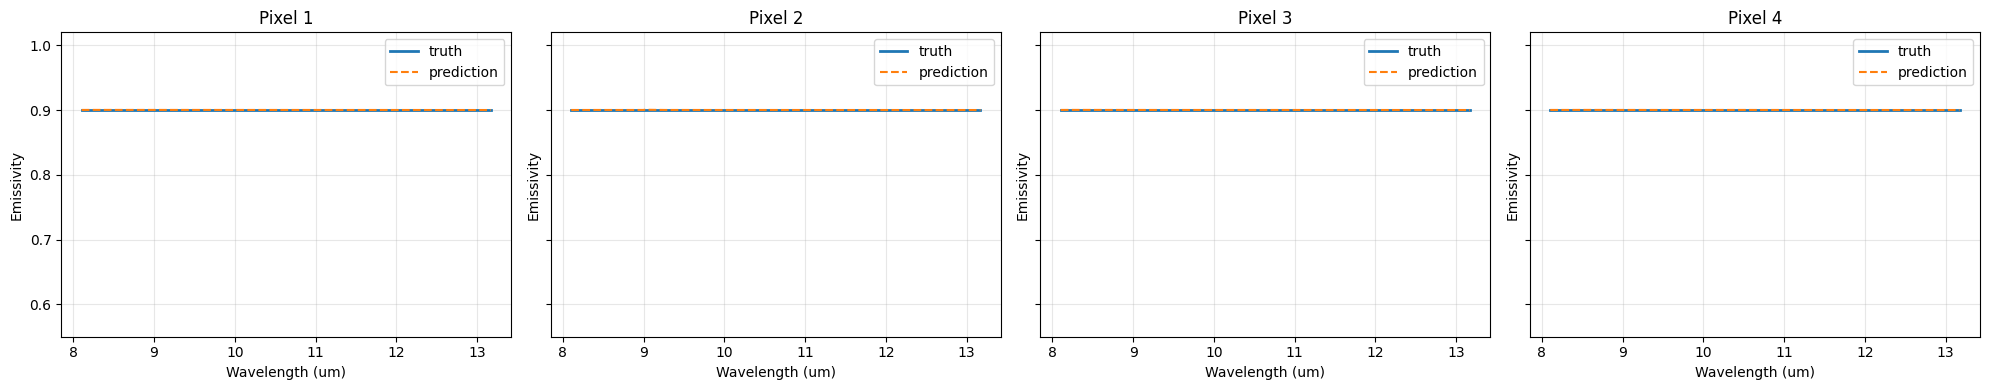

Selected-pixel emissivity RMSE: 0.00011150576756335795


In [89]:
selected_rows = np.array([pixel[0] for pixel in selected_pixels])
selected_cols = np.array([pixel[1] for pixel in selected_pixels])
selected_names = [pixel[3] for pixel in selected_pixels]

selected_small_rows = selected_rows // backward_stride
selected_small_cols = selected_cols // backward_stride
emissivity_truth_pixels = emissivity[selected_rows, selected_cols, :]
emissivity_prediction_pixels = result['emissivity'][selected_small_rows, selected_small_cols, :]

fig, axes = plt.subplots(1, len(selected_names), figsize=(5 * len(selected_names), 4), sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for i, (ax, material_name) in enumerate(zip(axes, selected_names)):
    ax.plot(wavelengths_um, emissivity_truth_pixels[i, :], label='truth', linewidth=2)
    ax.plot(wavelengths_um, emissivity_prediction_pixels[i, :], label='prediction', linestyle='--')
    ax.set_title(material_name)
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Emissivity')
    ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Selected-pixel emissivity RMSE:', float(np.sqrt(np.mean((emissivity_prediction_pixels - emissivity_truth_pixels) ** 2))))
